<a href="https://colab.research.google.com/github/21anonymous/Advance-nuclear-physics-lab-/blob/main/NaITl%20detector(3x3)%20efficiency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

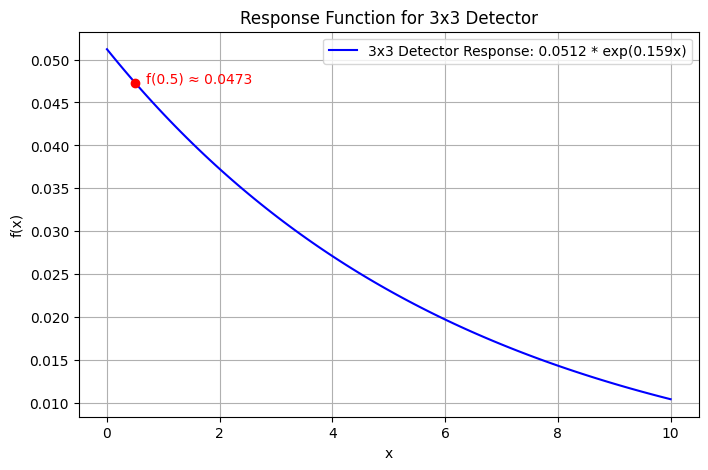

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function for 3x3 detector
def detector_response_3x3(x):
    return 0.0512 * np.exp(-0.159 * x)

# Generate x values
x_values = np.linspace(0, 10, 100)
y_values = detector_response_3x3(x_values)

# Calculate value at x = 0.5
x_mark = 0.5
y_mark = detector_response_3x3(x_mark)

# Plot the function
plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, label='3x3 Detector Response', color='blue')
plt.scatter(x_mark, y_mark, color='red', zorder=5)
plt.text(x_mark + 0.2, y_mark, f'f(0.5) ≈ {y_mark:.4f}', color='red')

# Plot decorations
plt.title('Response Function for eneergy 0.662 Mev ')
plt.xlabel('distance')
plt.ylabel('efficiency ')
plt.grid(True)
plt.legend()
plt.show()


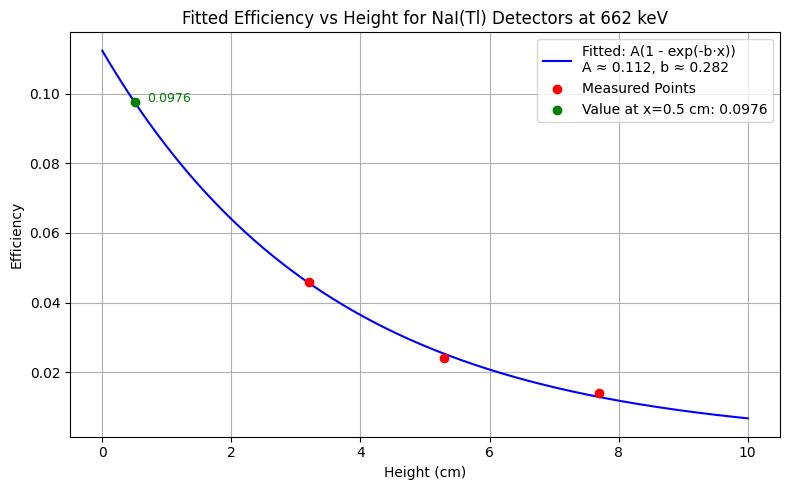

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data: height in cm and efficiency
heights = np.array([3.2,5.3,7.7])
efficiencies = np.array([0.046,0.024,0.014])

# Define the fitting function
def efficiency_model(x, A, b):
    return A * ( np.exp(-b * x))

# Fit the curve to the data
popt, pcov = curve_fit(efficiency_model, heights, efficiencies, p0=[1, 0.3])
A_fit, b_fit = popt

# Generate smooth curve for plotting
x_fit = np.linspace(0, 10, 200)
y_fit = efficiency_model(x_fit, A_fit, b_fit)

# Calculate value at x = 0.5
x_mark = 0.5
y_mark = efficiency_model(x_mark, A_fit, b_fit)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(x_fit, y_fit, label=f'Fitted: A(1 - exp(-b·x))\nA ≈ {A_fit:.3f}, b ≈ {b_fit:.3f}', color='blue')
plt.scatter(heights, efficiencies, color='red', label='Measured Points', zorder=5)
plt.scatter(x_mark, y_mark, color='green', label=f'Value at x=0.5 cm: {y_mark:.4f}', zorder=5)
plt.text(x_mark + 0.2, y_mark, f'{y_mark:.4f}', fontsize=9, color='green')

# Plot settings
plt.title('Fitted Efficiency vs Height for NaI(Tl) Detectors at 662 keV')
plt.xlabel('Height (cm)')
plt.ylabel('Efficiency')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


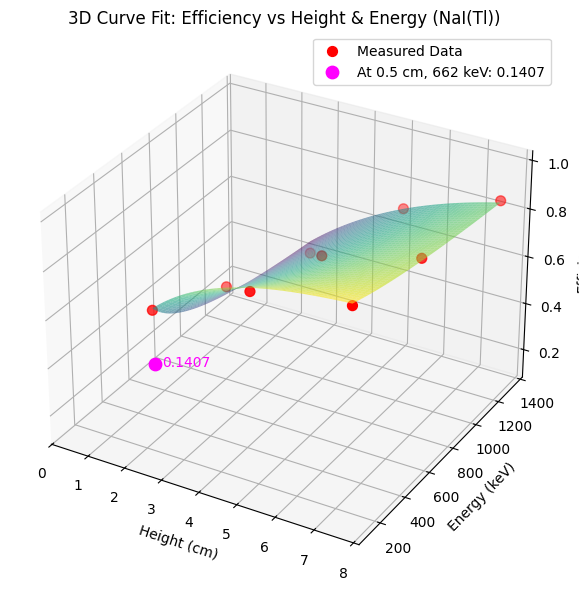

Fitted Parameters:
A = 0.9975, b = 2.3000, c = 0.3115
Efficiency at 0.5 cm and 662 keV: 0.1407


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import curve_fit

# ---------------------------
# ✅ Your real data goes here:
# ---------------------------
# Example mock data:
heights = np.array([0.01, 0.7,1,2,3,5,7,10,20,50])  # in cm
energies = np.array([5.5, 3.8, 2.04, 1.10, 0.566, 0.332,0.212]) # in MeV
efficiencies = np.array([0.33157,])

# Flatten the arrays just in case
xdata = np.vstack((heights, energies)).T
ydata = efficiencies

# ---------------------------
# 📘 Model function to fit:
# ---------------------------
def model(data, A, b, c):
    h, E = data[:, 0], data[:, 1]
    return A * (1 - np.exp(-b * h * E**(-c)))

# ---------------------------
# 🔧 Fit the model to the data
# ---------------------------
popt, _ = curve_fit(model, xdata, ydata, p0=[1, 1, 0.5])
A_fit, b_fit, c_fit = popt

# ---------------------------
# 📊 3D Plotting
# ---------------------------
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Surface grid
H_vals = np.linspace(min(heights), max(heights), 50)
E_vals = np.linspace(min(energies), max(energies), 50)
H_grid, E_grid = np.meshgrid(H_vals, E_vals)

# Predict efficiency on the grid
Eff_grid = model(np.column_stack((H_grid.ravel(), E_grid.ravel())), *popt).reshape(H_grid.shape)

# Plot surface
surf = ax.plot_surface(H_grid, E_grid, Eff_grid, alpha=0.6, cmap='viridis')

# Plot actual data points
ax.scatter(heights, energies, efficiencies, color='red', label='Measured Data', s=50)

# Mark value at h = 0.5 cm, E = 662 keV
h_target = 0.5
E_target = 662
eff_target = model(np.array([[h_target, E_target]]), *popt)[0]
ax.scatter(h_target, E_target, eff_target, color='magenta', s=80, label=f"At 0.5 cm, 662 keV: {eff_target:.4f}")
ax.text(h_target+0.2, E_target, eff_target, f"{eff_target:.4f}", color='magenta')

# Labels
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Energy (keV)")
ax.set_zlabel("Efficiency")
ax.set_title("3D Curve Fit: Efficiency vs Height & Energy (NaI(Tl))")
ax.legend()
plt.tight_layout()
plt.show()

# Print fitted parameters
print(f"Fitted Parameters:\nA = {A_fit:.4f}, b = {b_fit:.4f}, c = {c_fit:.4f}")
print(f"Efficiency at 0.5 cm and 662 keV: {eff_target:.4f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------
# 🧪 Your experimental data (replace with real values)
# ---------------------------
energies = np.array([5.5,2.04,1.1,0.566,0.332,0.212,0.152,0.129,0.105])
height = np.array([0.001,0.2,0.3,0.5,0.7,1,2,3,5])
efficiencies = np.array([0.33157,0.33536,0.37121,0.40401,0.42658,0.42463,0.36579,0.31104,0.22221])

# Create 2D input array
xdata = np.vstack((heights, energies)).T
ydata = efficiencies


#  Model to fit

def efficiency_model(data, A, b, c):
    h, E = data[:, 0], data[:, 1]
    return A * (np.exp(-b * h * E*(-c)))

popt, _ = curve_fit(efficiency_model, xdata, ydata, p0=[1, 1, 0.5])
A_fit, b_fit, c_fit = popt


predicted_eff = efficiency_model(xdata, *popt)
residuals = ydata - predicted_eff  # Discrepancy
mse = np.mean(residuals**2)

# Print results
print(f" Optimized parameters:")
print(f"A = {A_fit:.4f}, b = {b_fit:.4f}, c = {c_fit:.4f}")
print(f"Mean Squared Error (MSE): {mse:.6f}")

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(heights, energies, residuals, c='red', s=60, label="Residuals")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Energy (keV)")
ax.set_zlabel("Discrepancy (Measured - Model)")
ax.set_title("Residuals of Efficiency Model")
ax.legend()
plt.tight_layout()
plt.show()


# Grid for surface
H_vals = np.linspace(min(heights), max(heights), 50)
E_vals = np.linspace(min(energies), max(energies), 50)
H_grid, E_grid = np.meshgrid(H_vals, E_vals)
grid_data = np.column_stack((H_grid.ravel(), E_grid.ravel()))
Z_fit = efficiency_model(grid_data, *popt).reshape(H_grid.shape)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(H_grid, E_grid, Z_fit, cmap='viridis', alpha=0.7)
ax.scatter(heights, energies, efficiencies, c='red', s=50, label="Measured Data")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Energy (keV)")
ax.set_zlabel("Efficiency")
ax.set_title("3D Efficiency Fit with Measured Data")
ax.legend()
plt.tight_layout()
plt.show()




IndentationError: unindent does not match any outer indentation level (<tokenize>, line 22)


Fitted Equation:
Efficiency = 0.45076 * exp(-0.07062 * Energy - 0.12260 * Height)


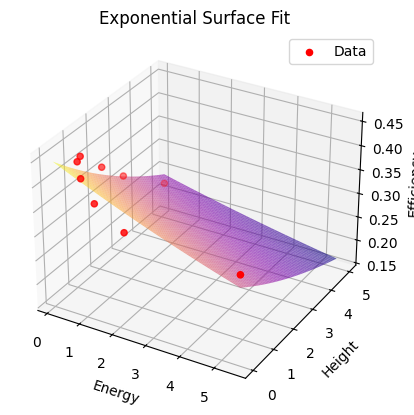

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Your data
energies = np.array([5.5, 2.04, 1.1, 0.566, 0.332, 0.212, 0.152, 0.129, 0.105])
height =   np.array([0.001, 0.2, 0.3, 0.5, 0.7, 1, 2, 3, 5])
efficiencies = np.array([0.33157, 0.33536, 0.37121, 0.40401, 0.42658, 0.42463, 0.36579, 0.31104, 0.22221])

# Define exponential model: Efficiency = A * exp(-b1*E - b2*H)
def model(data, A, b1, b2):
    E, H = data
    return A * np.exp(-b1 * E - b2 * H)

# Fit the model
popt, _ = curve_fit(model, (energies, height), efficiencies, p0=(1, 1, 1))
A, b1, b2 = popt

# Show fitted equation
print("\nFitted Equation:")
print(f"Efficiency = {A:.5f} * exp(-{b1:.5f} * Energy - {b2:.5f} * Height)")

# Meshgrid for surface plot
e_range = np.linspace(min(energies), max(energies), 50)
h_range = np.linspace(min(height), max(height), 50)
E_grid, H_grid = np.meshgrid(e_range, h_range)
Eff_grid = model((E_grid.ravel(), H_grid.ravel()), *popt).reshape(E_grid.shape)

# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(energies, height, efficiencies, color='red', label='Data')
ax.plot_surface(E_grid, H_grid, Eff_grid, alpha=0.6, cmap='plasma')
ax.set_xlabel('Energy')
ax.set_ylabel('Height')
ax.set_zlabel('Efficiency')
ax.set_title('Exponential Surface Fit')
plt.legend()
plt.show()



Fitted Efficiency Model (in %):
ξ(Eγ, h) = 1.25216 * (25.95264 + 4.57951/Eγ + -0.50752/Eγ²) * exp(-0.06542 * h)


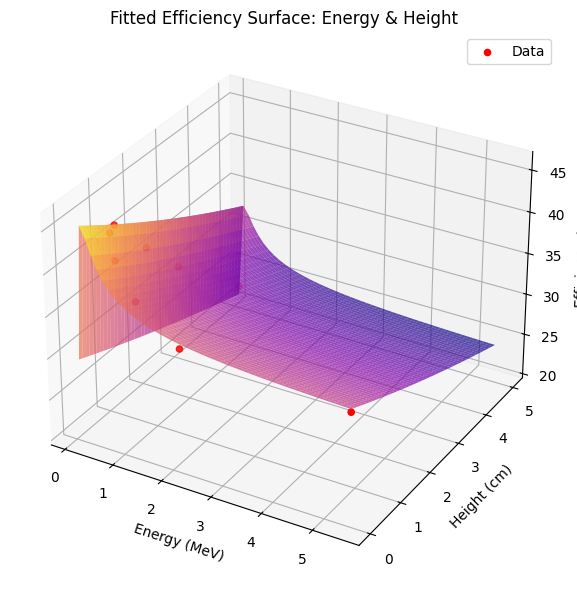

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Data
energies = np.array([5.5, 2.04, 1.1, 0.566, 0.332, 0.212, 0.152, 0.129, 0.105])
height =   np.array([0.001, 0.2, 0.3, 0.5, 0.7, 1, 2, 3, 5])
efficiencies = np.array([0.33157, 0.33536, 0.37121, 0.40401, 0.42658, 0.42463, 0.36579, 0.31104, 0.22221]) * 100  # Convert to %

# Define the model
def combined_model(data, A, b, l, m, n):
    E, h = data
    return A * (l + m/E + n/E**2) * np.exp(-b * h)

# Fit the model
popt, _ = curve_fit(combined_model, (energies, height), efficiencies, p0=(1, 0.1, 1, 1, 1))
A, b, l, m, n = popt

# Print the fitted equation
print("\nFitted Efficiency Model (in %):")
print(f"ξ(Eγ, h) = {A:.5f} * ({l:.5f} + {m:.5f}/Eγ + {n:.5f}/Eγ²) * exp(-{b:.5f} * h)")

# Create meshgrid for plotting
E_range = np.linspace(min(energies), max(energies), 50)
H_range = np.linspace(min(height), max(height), 50)
E_grid, H_grid = np.meshgrid(E_range, H_range)
ξ_grid = combined_model((E_grid.ravel(), H_grid.ravel()), *popt).reshape(E_grid.shape)

# 3D plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(energies, height, efficiencies, color='red', label='Data')
ax.plot_surface(E_grid, H_grid, ξ_grid, cmap='plasma', alpha=0.7)
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Height (cm)')
ax.set_zlabel('Efficiency (%)')
ax.set_title('Fitted Efficiency Surface: Energy & Height')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import plotly.graph_objs as go

# Your data
energies = np.array([5.5, 2.04, 1.1, 0.566, 0.332, 0.212, 0.152, 0.129, 0.105])
height =   np.array([0.001, 0.2, 0.3, 0.5, 0.7, 1, 2, 3, 5])
efficiencies = np.array([0.33157, 0.33536, 0.37121, 0.40401, 0.42658, 0.42463, 0.36579, 0.31104, 0.22221]) * 100

# Define model
def model(data, A, b, l, m, n):
    E, h = data
    return A * (l + m/E + n/E**2) * np.exp(-b * h)

# Fit curve
popt, _ = curve_fit(model, (energies, height), efficiencies, p0=(1, 0.1, 1, 1, 1))
A, b, l, m, n = popt

# Fitted function
def fitted_eff(E, h):
    return A * (l + m/E + n/E**2) * np.exp(-b * h)

# Meshgrid for surface
E_vals = np.linspace(min(energies), max(energies), 60)
H_vals = np.linspace(min(height), max(height), 60)
E_grid, H_grid = np.meshgrid(E_vals, H_vals)
Z = fitted_eff(E_grid, H_grid)

# Create plotly surface
surface = go.Surface(x=E_grid, y=H_grid, z=Z, colorscale='Viridis', opacity=0.7, name="Fitted Surface")

# Original data points
data_points = go.Scatter3d(
    x=energies, y=height, z=efficiencies,
    mode='markers',
    marker=dict(size=6, color='red'),
    name='Data Points'
)

# Mark specific point
target_energy = 0.622
target_height = 1  # Adjust this if you have a known height
target_eff = 50  # Efficiency in %

target_point = go.Scatter3d(
    x=[target_energy],
    y=[target_height],
    z=[target_eff],
    mode='markers+text',
    marker=dict(size=8, color='black', symbol='x'),
    text=["(0.622 MeV, 0.5 cm, 50%)"],
    textposition='top center',
    name='Marked Point'
)

# Layout
layout = go.Layout(
    scene=dict(
        xaxis_title='Energy (MeV)',
        yaxis_title='Height (cm)',
        zaxis_title='Efficiency (%)',
    ),
    title="3D Efficiency Fit with Marked Point",
    showlegend=True
)

# Plot
fig = go.Figure(data=[surface, data_points, target_point], layout=layout)
fig.show()


In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import plotly.graph_objs as go

# Your data
energies = np.array([5.5, 2.04, 1.1, 0.566, 0.332, 0.212, 0.152, 0.129, 0.105])
height =   np.array([0.001, 0.2, 0.3, 0.5, 0.7, 1, 2, 3, 5])
efficiencies = np.array([0.33157, 0.33536, 0.37121, 0.40401, 0.42658, 0.42463, 0.36579, 0.31104, 0.22221]) * 100

# Define model
def model(data, A, b, l, m, n):
    E, h = data
    return A * (l + m/E + n/E**2) * np.exp(-b * h)

# Fit curve
popt, _ = curve_fit(model, (energies, height), efficiencies)
A, b, h, m, n = popt

# Fitted function
def fitted_eff(E, h):
    return A * (l + m/E + n/E**2) * np.exp(-b * h)

# Generate meshgrid for surface
E_vals = np.linspace(min(energies), max(energies), 60)
H_vals = np.linspace(min(height), max(height), 60)
E_grid, H_grid = np.meshgrid(E_vals, H_vals)
Z = fitted_eff(E_grid, H_grid)

# Target point
target_energy = 0.662  # MeV
target_height = 0.5    # cm
target_eff = fitted_eff(target_energy, target_height)

# Plot components
surface = go.Surface(x=E_grid, y=H_grid, z=Z, colorscale='Viridis', opacity=1, name="Fitted Surface")

data_points = go.Scatter3d(
    x=energies, y=height, z=efficiencies,
    mode='markers',
    marker=dict(size=6, color='red'),
    name='Data Points'
)

marked_point = go.Scatter3d(
    x=[target_energy],
    y=[target_height],
    z=[target_eff],
    mode='markers+text',
    marker=dict(size=8, color='black', symbol='x'),
    text=[f"(0.662 MeV, 0.5 cm, {target_eff:.2f})"],
    textposition='top center',
    name='Marked Point'
)

layout = go.Layout(
    scene=dict(
        xaxis_title='Energy (MeV)',
        yaxis_title='Height (cm)',
        zaxis_title='Efficiency',
    ),
    title="3D Efficiency Fit with Marked Point at 0.662 MeV, 0.5 cm",
    showlegend=True
)

# Create figure
fig = go.Figure(data=[surface, data_points, marked_point], layout=layout)
fig.show()

